# Set-up colab


In [1]:
from fairness_metric_utils import *
from penalty_utils import *

# Load Data

In [2]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

### Without mapped groups

In [3]:
def compute_fairness_metrics_after(cm_dict, m):
  fairness_dict={}
  count_group= {}
  for group, cm in cm_dict.items():
    TP, TN, FP, FN, len_group = retrieve_values(cm)
    fairness_metric = 0
    if FP!=0:
      if m=='PPE':
        fairness_metric = (FP)/(TN+FP) #PredictiveEquality or FalsePositiveRate (FPR)
      elif m=='FPR':
        fairness_metric = (FP)/(TP+FP) #FalsDiscoveryRate
      elif m=='FPP':
        fairness_metric= (FP)/len_group #FalsePositiveParity
      elif m=='FPN':
        fairness_metric= (FP)/(FN+FP)
    if FN!=0:
      if m=='FPA':
        fairness_metric= (FN)/(TN+FN) #FORParity
      elif m=='EOP':
        fairness_metric= (FN)/(TP+FN) #EqualOpportunity
      elif m=='FNP':
        fairness_metric= (FN)/len_group #FalseNegativeParity
      elif m=='FNE':
        fairness_metric=(FN)/(FP+FN)
    if FP!=0 and FN!=0:
      if m=='ERR':
        fairness_metric= (FP+FN)/len_group #ErrorRate
    if TP!=0:
      if m=='GFA':
        fairness_metric = (TP+FP)/len_group #Group Fairness
      elif m=='PPA':
        fairness_metric = (TP)/(TP+FP) #Predictive Parity
      elif m=='OAE':
        fairness_metric= (TP+TN)/len_group #OverallAccuracyEquality
    if FP!=0 or FN!=0:
      fairness_dict[group] = fairness_metric
    else:
      print(f"Warning: Group {mapped_group} {group} has only FN. Skipping fairness metrics calculation.")
    count_group[group]= len_group # len_group = TN + FP + FN + TP
  count_group = convert_types(count_group)
  fairness_dict = convert_types(fairness_dict)  # Ensure Python-native types
  print("After: ", m, fairness_dict)
  return fairness_dict, count_group

### With Mapped Groups

In [4]:
def compute_fairness_metrics_and_counts(cm_dict, m, sensible_attribute, mapping, dataset_path):
  fairness_dict={}
  count_group= {}
  for group, cm in cm_dict.items():
    TP, TN, FP, FN, len_group = retrieve_values(cm)
    fairness_metric = 0
    if FP!=0:
      if m=='PPE':
        fairness_metric = (FP)/(TN+FP) #PredictiveEquality or FalsePositiveRate (FPR)
      elif m=='FPR':
        fairness_metric = (FP)/(TP+FP) #FalsDiscoveryRate
      elif m=='FPP':
        fairness_metric= (FP)/len_group #FalsePositiveParity
      elif m=='FPN':
        fairness_metric= (FP)/(FN+FP)
    if FN!=0:
      if m=='FPA':
        fairness_metric= (FN)/(TN+FN) #FORParity
      elif m=='EOP':
        fairness_metric= (FN)/(TP+FN) #EqualOpportunity
      elif m=='FNP':
        fairness_metric= (FN)/len_group #FalseNegativeParity
      elif m=='FNE':
        fairness_metric=(FN)/(FP+FN)
    if FP!=0 and FN!=0:
      if m=='ERR':
        fairness_metric= (FP+FN)/len_group #ErrorRate
    if TP!=0:
      if m=='GFA':
        fairness_metric = (TP+FP)/len_group #Group Fairness
      elif m=='PPA':
        fairness_metric = (TP)/(TP+FP) #Predictive Parity
      elif m=='OAE':
        fairness_metric= (TP+TN)/len_group #OverallAccuracyEquality
    if FP!=0 or FN!=0:
      fairness_dict[group] = fairness_metric
    else:
      mapped_group = mapping_numbers_into_labels(group, sensible_attribute, mapping, dataset_path)
      print(f"Warning: Group {mapped_group} {group} has only FN. Skipping fairness metrics calculation.")
    count_group[group]= len_group # len_group = TN + FP + FN + TP
  count_group = convert_types(count_group)
  fairness_dict = convert_types(fairness_dict)  # Ensure Python-native types
  print(m, fairness_dict)
  return fairness_dict, count_group

## Classifier and Predictions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Testing 30%

X_train, X_test: features to train and evaluate the model

y_test: real labels

y_pred: model's predicted labels for the test data

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1


In [5]:
def compute_predictions(df, target_variable, sensible_attribute, target, target_variable_labels=['0','1']):
  Y = df[target_variable]
  X = df.drop(target_variable, axis=1)
  X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
  # TODO: Split test to validation and test. 
  sensible_indexes=df[sensible_attribute].loc[list(X_test.index)]
  model = RandomForestClassifier(random_state = 1234).fit(X_train,y_train)
  #feature_importance(model, X, X.columns)
  y_pred = model.predict(X_test) # TODO: on validation 
  cm =confusion_matrix(y_test, y_pred, labels=target_variable_labels)
  print(sensible_attribute)
  performance_metrics(y_test, y_pred)
  return sensible_indexes, y_pred, y_test, X_test, X_train, y_train

Compute the previous functions, plus the confusion matrix for...

In [6]:
def get_test_pred_fairness(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels=['0','1']):
  sensible_indexes={}
  y_pred= []
  y_test= []
  sensible_indexes, y_pred, y_test, X_test, X_train, y_train= compute_predictions(df, target_variable, sensible_attribute, target_variable_labels)
  cm_dict={}
  fairness_metrics_dict={}
  cm_dict= compute_cm_group(df, sensible_attribute, sensible_indexes, y_pred, y_test, X_test, target_variable_labels)
  for m in fair_metrics:
    fairness_metrics_dict[m], count_groups = compute_fairness_metrics_and_counts(cm_dict, m, sensible_attribute, mapping, dataset_path)
  return y_train, X_train, X_test, y_test, y_pred, fairness_metrics_dict, count_groups

### Build the dictionaries 

For X and y training, testing, prediction, fairness metrics and group counts, for each subgroup. 

In the form {Subgroup: data}

Using the functions above

In [7]:
pairs_dict= {}
fairness_metrics_dict= {}
X_train = {}
y_train = {}
X_test ={}
y_test = {}
y_pred= {}
group_counts= {}
s= []
for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    y_train[sensible_attribute], X_train[sensible_attribute], X_test[sensible_attribute], y_test[sensible_attribute], y_pred[sensible_attribute], fairness_metrics_dict[sensible_attribute], group_counts[sensible_attribute] = get_test_pred_fairness(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping,target_variable_labels)

['age']
age
Precision: 0.7341650671785028, Recall: 0.6372344856309871, Accuracy: 0.8541304125294298, F1: 0.6822742474916388
FPN {1: 0.4748768472906404, 0: 0.17560975609756097}
['sex']
sex
Precision: 0.7341650671785028, Recall: 0.6372344856309871, Accuracy: 0.8541304125294298, F1: 0.6822742474916388
FPN {0: 0.22083333333333333, 1: 0.42278481012658226}
['race']
race
Precision: 0.7341650671785028, Recall: 0.6372344856309871, Accuracy: 0.8541304125294298, F1: 0.6822742474916388
FPN {1: 0.40483383685800606, 0: 0.1782178217821782}
['edu']
edu
Precision: 0.7341650671785028, Recall: 0.6372344856309871, Accuracy: 0.8541304125294298, F1: 0.6822742474916388
FPN {0: 0.09090909090909091, 1: 0.526694045174538}
['age', 'sex']
age-sex
Precision: 0.7343599615014437, Recall: 0.6355685131195336, Accuracy: 0.8539256832838571, F1: 0.6814020986827417
FPN {'10': 0.2360248447204969, '00': 0.19230769230769232, '11': 0.5198598130841121, '01': 0.16265060240963855}
['age', 'race']
age-race
Precision: 0.7309913378

In [8]:
print(y_pred)

{'age': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'sex': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'race': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-sex': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-race': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'sex-race': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'sex-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'race-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-sex-race': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-sex-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-race-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'sex-race-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,)), 'age-sex-race-edu': array([0, 1, 0, ..., 0, 0, 1], shape=(9769,))}


In [9]:
print(y_test)

{'age': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: income, Length: 9769, dtype: int64, 'sex': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: income, Length: 9769, dtype: int64, 'race': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: income, Length: 9769, dtype: int64, 'edu': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: income, Length: 9769, dtype: int64, 'age-sex': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: income, Length: 9769, dtype: int64, 'age-race': 9646     0
709      1
7385     0
16671    0
21932    0
        ..
29663    0
29310    0
29661    0
19491    0
2861     1
Name: incom

In [10]:
print(X_test['sex-race'])

       age  edu  marital.status  relationship  capital.gain  capital.loss  \
9646     0    0               0             1             0             0   
709      0    1               2             0             0          1902   
7385     0    0               4             3             0             0   
16671    1    1               2             0             0             0   
21932    0    1               4             1             0             0   
...    ...  ...             ...           ...           ...           ...   
29663    0    0               4             4             0             0   
29310    1    0               2             0             0             0   
29661    0    1               4             3             0             0   
19491    0    1               4             1             0             0   
2861     1    1               2             0          7298             0   

       hours.per.week sex-race  
9646               50       00  
709      

In [11]:
print(fairness_metrics_dict['sex-race'])

{'FPN': {'01': 0.2374429223744292, '00': 0.09090909090909091, '11': 0.43541102077687444, '10': 0.20512820512820512}}


In [12]:
print(group_counts['sex-race'])

{'01': 2726, '00': 533, '11': 5929, '10': 581}


# Compute Penalty

Every subgroup and attribute combination, for each metric.

In [13]:
def harmonic_mean_2(a,b):
  return (2)/((1/a)+(1/b))

def harmonic_mean_3(a,b,c):
  return (3)/((1/a)+(1/b)+(1/c))

def harmonic_mean_4(a,b,c,d):
  return (4)/((1/a)+(1/b)+(1/c)+(1/d))

# Penalty computation for each subgroup combination k
def compute_penalty(actual_values, predicted_values):
  penalties= {}
  # k = subgroup combination (00, 01, 10, etc...)
  for k in actual_values.keys():
    penalties[k] = penalty_percentage(actual_values[k], predicted_values[k])
  return penalties

def penalty_percentage(actual_value, predicted_value):
  return ((predicted_value-actual_value)*100)/predicted_value

def actual_predicted_values_2(fairness_metrics_dict, df, s1, s2, m):
  actual_values= {}
  predicted_values= {}
  s3 = str(s1)+'-'+str(s2)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m]:
        a = fairness_metrics_dict[s1][m][i]
        b = fairness_metrics_dict[s2][m][j]
        k=str(i)+str(j)
        if k in fairness_metrics_dict[s3][m]:
          c = fairness_metrics_dict[s3][m][k]
        else:
          c = 0
        actual_values[k]= c
        predicted_values[k]= harmonic_mean_2(a,b)
  return actual_values, predicted_values

def actual_predicted_values_3(fairness_metrics_dict, df, s1, s2, s3, m):
  actual_values= {}
  predicted_values= {}
  s4 = str(s1)+'-'+str(s2)+'-'+str(s3)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      for k in range(0,df[s3].nunique()):
        if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m] and k in fairness_metrics_dict[s3][m]:
          a = fairness_metrics_dict[s1][m][i]
          b = fairness_metrics_dict[s2][m][j]
          c = fairness_metrics_dict[s3][m][k]
          w=str(i)+str(j)+str(k)
          if w in fairness_metrics_dict[s4][m]:
            d = fairness_metrics_dict[s4][m][w]
          else:
            d = 0
          actual_values[w]= d
          predicted_values[w]= harmonic_mean_3(a,b,c)
  return actual_values, predicted_values

def actual_predicted_values_4(fairness_metrics_dict, df, s1, s2, s3, s4, m):
  actual_values= {}
  predicted_values= {}
  s5 = str(s1)+'-'+str(s2)+'-'+str(s3)+'-'+str(s4)
  for i in range(0,df[s1].nunique()):
    for j in range(0,df[s2].nunique()):
      for k in range(0,df[s3].nunique()):
        for l in range(0,df[s4].nunique()):
          if i in fairness_metrics_dict[s1][m] and j in fairness_metrics_dict[s2][m] and k in fairness_metrics_dict[s3][m] and l in fairness_metrics_dict[s4][m]:
            a = fairness_metrics_dict[s1][m][i]
            b = fairness_metrics_dict[s2][m][j]
            c = fairness_metrics_dict[s3][m][k]
            d = fairness_metrics_dict[s4][m][l]
            w=str(i)+str(j)+str(k)+str(l)
            if w in fairness_metrics_dict[s5][m]:
              e = fairness_metrics_dict[s5][m][w]
            else:
              e= 0
            actual_values[w]= e
            predicted_values[w]= harmonic_mean_4(a,b,c,d)
  return actual_values, predicted_values

values= {}
penalties_across_metrics= {}
for m in fair_metrics:
  print(m)
  df=pd.read_csv(dataset_path)
  actual_values= {}
  predicted_values= {}
  penalties= {}
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        s1, s2 = sensible_attribute.split('-')
        # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_dict, df,s1, s2, m)
        print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

        # Build dictionary for penalty calculation of each attribute and subgroup combination. 
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==3:
        s1, s2, s3 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_3(fairness_metrics_dict, df,s1, s2, s3, m)
        print(s1, s2, s3, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==4:
        s1, s2, s3, s4 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_4(fairness_metrics_dict, df,s1, s2, s3, s4, m)
        print(s1, s2, s3, s4, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      
      values[m]= [actual_values, predicted_values]
      penalties_across_metrics[m]= penalties # The penalties dictionary itself didn't include m before
print(penalties)

#print(values['FPP'])


FPN
age sex {'00': 0.19230769230769232, '01': 0.16265060240963855, '10': 0.2360248447204969, '11': 0.5198598130841121} {'00': 0.19564214304024607, '01': 0.2481477659684243, '10': 0.30147219353887, '11': 0.44731935703469067}
{'00': 1.704362199645205, '01': 34.45413390087295, '10': 21.709248886310544, '11': -16.21670399651311}
age race {'00': 0.08695652173913043, '01': 0.17766497461928935, '10': 0.1951219512195122, '11': 0.5} {'00': 0.17690417690417687, '01': 0.24496013812014422, '10': 0.259170749193452, '11': 0.4370669120831529}
{'00': 50.84541062801931, '01': 27.47188339183945, '10': 24.712973270811542, '11': -14.39895955905121}
age edu {'00': 0.11538461538461539, '01': 0.1830065359477124, '10': 0.08045977011494253, '11': 0.6770833333333334} {'00': 0.11980033277870217, '01': 0.2633977280020538, '10': 0.1526040842171917, '11': 0.49944504086700875}
{'00': 3.6858974358974343, '01': 30.52083731478297, '10': 47.27548051700291, '11': -35.56713510618795}
sex race {'00': 0.09090909090909091, '

In [14]:
m = 'FPN'  
print(penalties_across_metrics[m]['sex-race'])
print(fairness_metrics_dict['sex-race'][m])
print(group_counts['sex-race'])

{'00': 53.911759100438346, '01': 16.913365454968634, '10': 18.190968490369677, '11': -5.269729924933535}
{'01': 0.2374429223744292, '00': 0.09090909090909091, '11': 0.43541102077687444, '10': 0.20512820512820512}
{'01': 2726, '00': 533, '11': 5929, '10': 581}


# Make the model using the sample weights

`sample_weight = weights`

Evaluating performance metrics (Precision, Recall, Accuracy, F1)
$\rightarrow$ We hope: $\geq$ 0.8

Comparing the before and after, for g=['sex-race'], m = 'fpn'. 

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [16]:
X_test['age-sex']

,edu,marital.status,relationship,race,capital.gain,capital.loss,hours.per.week,age-sex
9646,0,0,1,0,0,0,50,00
709,1,2,0,1,0,1902,48,01
7385,0,4,3,0,0,0,40,01
16671,1,2,0,1,0,0,40,11
21932,1,4,1,1,0,0,40,00
...,...,...,...,...,...,...,...,...
29663,0,4,4,1,0,0,40,01
29310,0,2,0,1,0,0,40,11
29661,1,4,3,1,0,0,40,00
19491,1,4,1,1,0,0,40,00


In [ ]:
def model_with_sample_weights(X_train, y_train, X_test, y_test, weights):
  # Model on validation and predict on test
  model = GradientBoostingClassifier(random_state = 1234).fit(X_test['sex-race'],y_test['sex-race'], sample_weight=weights)
  y_pred_on_train = model.predict(X_train['sex-race'])

  # --------------------------------- 
  # import xgboost as xgb
  
  # # Convert string combinations to numeric codes for BOTH train and test
  # X_test_numeric = X_test['sex-race'].copy()
  # X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes
  
  # X_train_numeric = X_train['sex-race'].copy()
  # X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes
  
  # model = xgb.XGBClassifier(random_state = 1234, use_label_encoder=False, eval_metric='logloss')
  # model.fit(X_test_numeric, y_test['sex-race'], sample_weight=weights)
  # y_pred_on_train = model.predict(X_train_numeric)

  # ---------------------------------

  # Attempts to increase precision by using predict_proba and thresholding at --
  # Results: false positives are reduced but also true positives (recall decrease)
  # probs = model.predict_proba(X_train['sex-race'])[:, 1]  
  # threshold = 0.53
  # y_pred_on_train = (probs >= threshold).astype(int)


  sensible_indexes=X_train['sex-race']['sex-race'].loc[list(X_train['sex-race'].index)]
  cm = confusion_matrix(y_train['sex-race'], y_pred_on_train, labels=[0,1])
  print(cm)

  performance_metrics(y_train['sex-race'], y_pred_on_train)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  #df, sensible_attribute, sensible_indexes, y_pred, y_test, X_test, target_variable_labels=['0','1']
  cm_dict= compute_cm_group(df, 'sex-race', sensible_indexes, y_pred_on_train, y_train['sex-race'], X_train['sex-race'], [0,1])
  for m in fair_metrics:
    fairness_metrics_dict_after[m], count_groups_after = compute_fairness_metrics_after(cm_dict, m)

  print("")
  for k in fairness_metrics_dict_after[m].keys():
    a = fairness_metrics_dict[sensible_attribute][m][k]
    b = fairness_metrics_dict_after[m][k] # No sensible attribute because its only one: sex-race, m = fpn
    diff=b-a

    # print(f"ATTRIBUTES {k}: before = {a}, after = {b}")
    # print(f'Difference (after - before): delta = {str(diff)} \n')


# Computing Weights - Functions

$w_i = 1 + \lambda * Penalty(g_i) $

In [18]:
"""
Compute sample weights based on intersectional penalties for collapsed string groups.

Parameters:
  df (pd.DataFrame): Dataset with true labels, predictions, and group column.
  y_true_col (str): Column name of ground truth labels.
  y_pred_col (str): Column name of model predictions.
  group_col (str): Column name of the combined group (e.g., "sex-race").
  penalties (dict): Mapping from group strings (e.g., "femaleBlack") to penalty scores.
  pattern_counts (dict): Optional dictionary of group counts.
  lambda_ (float): Reweighting strength.
  focus_on (str): Type of error to apply reweighting on.
  normalize_counts (bool): Whether to normalize pattern counts.

Returns:
  pd.Series: Sample weights.
"""
def compute_sample_weights_flat_group(df, y_true_col, y_pred_col, group_col, penalties, pattern_counts, lambda_=1.0, focus_on="fp"):

    weights = np.ones(len(df))  # Initialize weights to 1
    for i in range(len(df)):
        # Get the group for this row (sex-race) (attribute value combination)
        group = df.iloc[i][group_col]

        # Get the predicted and actual values for this row
        y_true = df.iloc[i][y_true_col]
        y_pred = df.iloc[i][y_pred_col]

        # Apply conditions for False Positives (or False Negatives, depending on focus)
        if focus_on == "fp" and y_true == 0 and y_pred == 1:
            # False positive — compute penalty and weight
            penalty = penalties.get(group, 0) # get value of the penalty for group
            weight = 1 + lambda_ * (penalty / 100)  # Scale the penalty

            # Debugging output: print row index, group, penalty, and computed weight
            print(f"Row {i}, group={group}, penalty={penalty:.2f}, weight={weight:.2f}")

            # Assign the computed weight
            weights[i] = weight

        elif focus_on == "fn" and y_true == 1 and y_pred == 0:
            # False negative — compute penalty and weight (similar logic as above)
            penalty = penalties.get(group, 0)
            weight = 1 + lambda_ * (penalty / 100)
            weights[i] = weight

        # Optional: add more conditions for other focuses like "tn" or "tp" if needed

    # List of weights where the index corresponds to the row i in df (assigning more importance to it)
    return weights


$w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [19]:
"""
Compute sample weights based on intersectional penalties for collapsed string groups.

Parameters:
  df (pd.DataFrame): Dataset with true labels, predictions, and group column.
  y_true_col (str): Column name of ground truth labels.
  y_pred_col (str): Column name of model predictions.
  group_col (str): Column name of the combined group (e.g., "sex-race").
  penalties (dict): Mapping from group strings (e.g., "femaleBlack") to penalty scores.
  pattern_counts (dict): Optional dictionary of group counts.
  lambda_ (float): Reweighting strength.
  focus_on (str): Type of error to apply reweighting on.
  normalize_counts (bool): Whether to normalize pattern counts.

Returns:
  pd.Series: Sample weights.
"""
def compute_weights(df, y_true_col, y_pred_col, group_col, penalties, pattern_counts, lambda_=2.0):

    weights = np.ones(len(df))  # Initialize weights to 1
    group_counts = df[group_col].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)
    for i in range(len(df)):
      # Get the predicted and actual values for this row
      y_true = df.iloc[i][y_true_col]
      y_pred = df.iloc[i][y_pred_col]
      if (y_true == 1 and y_pred == 0) or (y_true == 0 and y_pred == 1):
        # Get the group for this row (sex-race) - attribute value combination
        group = df.iloc[i][group_col]

        # Get the predicted and actual values for this row
        y_true = df.iloc[i][y_true_col]
        y_pred = df.iloc[i][y_pred_col]

        group_size = group_counts.get(group, 1)
        # False positive — compute penalty and weight
        penalty = penalties.get(group, 0) # get value of the penalty for attribute value (e.g. 01)
        weight = 1 + lambda_ * (penalty / 100) * (group_size/max_group_size)  # Scale the penalty

        # Debugging output: print row index, group, penalty, and computed weight
        print(f"Row {i}, group={group}, group_size={group_size}, max_group_size={max_group_size}, penalty={penalty:.2f}, weight={weight:.2f}")

        # Assign the computed weight
        weights[i] = weight

    return weights


# Generalizing for multiple fairness metrics

In [47]:
import numpy as np
import pandas as pd
from collections import defaultdict

def compute_sample_weights_flat_group_metrics(df, y_true, y_pred, group_col, lambda_=1.0, focus_on="fpn"):
    # Initialize weights to 1
    weights = np.ones(len(df))

    # Create a DataFrame for convenience
    data = df.copy()
    data["y_true"] = y_true
    data["y_pred"] = y_pred

    # Step 1: Compute FP and FN counts per group
    group_stats = defaultdict(lambda: {"fp": 0, "fn": 0, "tn": 0, "tp": 0})

    for _, row in data.iterrows():
        g = row[group_col] # Attribute value combination for subgroup "group_col"
        yt, yp = row["y_true"], row["y_pred"] # true and pred value for that row

        if yp == 1 and yt == 0:
            group_stats[g]["fp"] += 1
        elif yp == 0 and yt == 1:
            group_stats[g]["fn"] += 1
        elif yp == 0 and yt == 0:
            group_stats[g]["tn"] += 1
        elif yp == 1 and yt == 1:
            group_stats[g]["tp"] += 1

    # Step 2: Compute metric per group
    metric_per_group = {}
    for g, counts in group_stats.items(): # tuple (attribute_value, {fp: x, fn: y})
        fp = counts["fp"]
        fn = counts["fn"]
        tn = counts["tn"]
        tp = counts["tp"]

        if focus_on == "fpn" or focus_on == "fne":
            denom = fp + fn
            if focus_on == "fpn":
                metric_per_group[g] = fp / denom if denom > 0 else 0.0
            else:
                metric_per_group[g] = fn / denom if denom > 0 else 0.0
        elif focus_on == "ppe":
            denom = tn + fp
            metric_per_group[g] = fp / denom if denom > 0 else 0.0
        # Add more metrics as needed
        

    # Step 3: Compute marginal metrics (i.e., individual attribute values)
    marginals = defaultdict(lambda: {"fp": 0, "fn": 0, "tn": 0, "tp": 0})
    for idx, row in data.iterrows():
        g = row[group_col]
        yt, yp = row["y_true"], row["y_pred"]
        for attr_val in str(g): # independent attribute value: 0 or 1
            if yp == 1 and yt == 0:
                marginals[attr_val]["fp"] += 1
            elif yp == 0 and yt == 1:
                marginals[attr_val]["fn"] += 1
            elif yp == 0 and yt == 0:
                marginals[attr_val]["tn"] += 1
            elif yp == 1 and yt == 1:
                marginals[attr_val]["tp"] += 1

    metric_marginals = {}
    for val, counts in marginals.items(): # tuple (attribute_value, {fp: x, fn: y})
        fp = counts["fp"]
        fn = counts["fn"]
        tn = counts["tn"]
        tp = counts["tp"]

        if focus_on == "fpn" or focus_on == "fne":
            denom = fp + fn
            if focus_on == "fpn":
                metric_marginals[val] = fp / denom if denom > 0 else 0.0
            else:
                metric_marginals[val] = fn / denom if denom > 0 else 0.0
        elif focus_on == "ppe":
            denom = tn + fp
            metric_marginals[val] = fp / denom if denom > 0 else 0.0
        # Add more metrics as needed

    # Step 4: Compute expected metric using mean aggregation
    predicted_metric = {}
    for g in metric_per_group:
        # Assumes group is encoded like '01', '10', etc. 
        # Creates a list of the form ['0','1']
        attr_vals = list(str(g)) 

        # Get the (marginal) metric value for each independent attribute value '0' or '1' to compute mean
        mean_val = np.mean([metric_marginals.get(a, 0) for a in attr_vals])
        predicted_metric[g] = mean_val

    # Step 5: Compute penalty and weights
    for i in range(len(df)):
        # for every row i corresponding to column group_col, get the attribute value combination
        g = df.iloc[i][group_col]

        # Get the fpn value of g (attribute value combination)
        actual = metric_per_group.get(g, 0) 
        predicted = predicted_metric.get(g, 1)  # Avoid division by 0

        penalty = 100 * (predicted - actual) / predicted if predicted != 0 else 0
        weight = 1 + lambda_ * (penalty / 100) 
        weights[i] = weight

    return weights

```python
# group = df.iloc[i][group_col]
group = df.iloc[i]['sex-race']
group_size = group_counts.get(group, 1)
max_group_size = max(group_counts.values())
weight = 1 + lambda_ * (penalty / 100) * (group_size/max_group_size)  # Scale the penalty
```

## Weight Calculation Implementation

Calculating the weights using the functions above

m = FPN

Currently, `penalties_across_metrics` has only one metric: FPN, for all attribute combinations and attribute values. 

### Prepare the dataset
Prepare dataset to make the model (merge the attributes into one column and drop the individual ones)

In [25]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

# Implementing weights
## Comparing performance, fairness metrics

$w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [42]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')

# Create a copy of the X_test df for the sensible attribute (all features)
df=X_test['sex-race'].copy()

# Add true and predicted labels to df
df["y_true"]= y_test[sensible_attribute]
df["y_pred"]= y_pred[sensible_attribute]

weights = compute_weights(
    df=df,
    y_true_col="y_true",
    y_pred_col="y_pred",
    group_col="sex-race",
    penalties=penalties_across_metrics[m]['sex-race'],
    pattern_counts=group_counts['sex-race'],
    lambda_=5.0,
)
print(weights)
weights_formula = weights

Row 3, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 11, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 18, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 19, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 29, group=01, group_size=2726, max_group_size=5929, penalty=16.91, weight=1.39
Row 46, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 50, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 64, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 73, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 75, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 84, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 86, group=11, group_size=5929, max_group_size=5929, penalty=-5.27, weight=0.74
Row 1

In [27]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

model_with_sample_weights(X_train, y_train, X_test, y_test, weights_formula)

C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[15938  1414]
 [ 1979  3461]]
Precision: 0.7099487179487179, Recall: 0.6362132352941177, Accuracy: 0.8511319761319761, F1: 0.6710615608337372
After:  FPN {'01': 0.34791252485089463, '00': 0.21153846153846154, '11': 0.43252336448598133, '10': 0.43558282208588955}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.34791252485089463
Difference (after - before): delta = 0.11046960247646542 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.21153846153846154
Difference (after - before): delta = 0.12062937062937062 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.43252336448598133
Difference (after - before): delta = -0.0028876562908931036 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.43558282208588955
Difference (after - before): delta = 0.23045461695768443 



Precision: 0.6851666999401078, Recall: 0.6308823529411764, Accuracy: 0.8427079677079677, F1: 0.6569049669824863

GradientBossting: Precision: 0.7151347909148801, Recall: 0.6193014705882353, Accuracy: 0.8502544752544753, F1: 0.663776967786425

XGBOOST: Precision: 0.7099487179487179, Recall: 0.6362132352941177, Accuracy: 0.8511319761319761, F1: 0.6710615608337372


---

$w_i = 1 + \lambda * Penalty(g_i) $

In [28]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=X_test['sex-race'].copy()
df["y_true"]= y_test[sensible_attribute]
df["y_pred"]= y_pred[sensible_attribute]

weights = compute_sample_weights_flat_group(
    df=df,
    y_true_col="y_true",
    y_pred_col="y_pred",
    group_col="sex-race",
    penalties=penalties_across_metrics[m]['sex-race'],
    pattern_counts=group_counts['sex-race'],
    lambda_=2.0,
    focus_on="fp"
)

print(weights)
weights_notsized = weights

Row 3, group=11, penalty=-5.27, weight=0.89
Row 46, group=11, penalty=-5.27, weight=0.89
Row 64, group=11, penalty=-5.27, weight=0.89
Row 75, group=11, penalty=-5.27, weight=0.89
Row 86, group=11, penalty=-5.27, weight=0.89
Row 134, group=11, penalty=-5.27, weight=0.89
Row 140, group=11, penalty=-5.27, weight=0.89
Row 177, group=11, penalty=-5.27, weight=0.89
Row 189, group=11, penalty=-5.27, weight=0.89
Row 193, group=11, penalty=-5.27, weight=0.89
Row 209, group=11, penalty=-5.27, weight=0.89
Row 228, group=11, penalty=-5.27, weight=0.89
Row 266, group=11, penalty=-5.27, weight=0.89
Row 278, group=11, penalty=-5.27, weight=0.89
Row 285, group=11, penalty=-5.27, weight=0.89
Row 293, group=11, penalty=-5.27, weight=0.89
Row 321, group=11, penalty=-5.27, weight=0.89
Row 353, group=11, penalty=-5.27, weight=0.89
Row 359, group=11, penalty=-5.27, weight=0.89
Row 367, group=11, penalty=-5.27, weight=0.89
Row 370, group=11, penalty=-5.27, weight=0.89
Row 372, group=11, penalty=-5.27, weight

In [29]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

model_with_sample_weights(X_train, y_train, X_test, y_test, weights_notsized)

C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[15848  1504]
 [ 1908  3532]]
Precision: 0.7013502779984114, Recall: 0.649264705882353, Accuracy: 0.8502983502983503, F1: 0.67430316914853
After:  FPN {'01': 0.29938900203665986, '00': 0.18, '11': 0.4728682170542636, '10': 0.41358024691358025}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.29938900203665986
Difference (after - before): delta = 0.061946079662230646 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.18
Difference (after - before): delta = 0.08909090909090908 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.4728682170542636
Difference (after - before): delta = 0.03745719627738914 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.41358024691358025
Difference (after - before): delta = 0.20845204178537513 



Precision: 0.6740754933895382, Recall: 0.6466911764705883, Accuracy: 0.8410407160407161, F1: 0.6600994464771555

Gradient Boosting: Precision: 0.7013483598309519, Recall: 0.640625, Accuracy: 0.8491137241137241, F1: 0.6696128350465943

XGBOOST: Precision: 0.7013502779984114, Recall: 0.649264705882353, Accuracy: 0.8502983502983503, F1: 0.67430316914853


---

$w_i = 1 + \lambda * Penalty(g_i) $

With penalty computed, focused on FPN

In [48]:
df=X_test['sex-race'].copy()
weights= compute_sample_weights_flat_group_metrics(
    df, 
    y_test[sensible_attribute], 
    y_pred[sensible_attribute], 
    "sex-race", 
    lambda_=1.0, 
    focus_on="fpn")
print(weights)
weights_fpn = weights

[1.56944444 0.94058423 1.34056725 ... 1.23668401 1.23668401 0.94058423]


In [51]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

model_with_sample_weights(X_train, y_train, X_test, y_test, weights_fpn)

[[15863  1489]
 [ 1956  3484]]
Precision: 0.7005831490046249, Recall: 0.6404411764705882, Accuracy: 0.8488504738504739, F1: 0.6691635455680399
After:  FPN {'01': 0.2736625514403292, '00': 0.07547169811320754, '11': 0.46625319226559647, '10': 0.4484848484848485}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.2736625514403292
Difference (after - before): delta = 0.03621962906589998 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.07547169811320754
Difference (after - before): delta = -0.015437392795883367 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.46625319226559647
Difference (after - before): delta = 0.030842171488722037 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.4484848484848485
Difference (after - before): delta = 0.24335664335664337 



Precision: 0.6754352030947776, Recall: 0.6419117647058824, Accuracy: 0.8409090909090909, F1: 0.6582469368520264

Gradient Boosting: Precision: 0.7005831490046249, Recall: 0.6404411764705882, Accuracy: 0.8488504738504739, F1: 0.6691635455680399

XGBOOST: Precision: 0.7029505582137161, Recall: 0.6481617647058824, Accuracy: 0.8506493506493507, F1: 0.6744452945677123

---

$w_i = 1 + \lambda * Penalty(g_i) $

With penalty computed, focused on PPE

In [52]:
df=X_test['sex-race'].copy()
weights= compute_sample_weights_flat_group_metrics(
    df, 
    y_test[sensible_attribute], 
    y_pred[sensible_attribute], 
    "sex-race", 
    lambda_=1.0, 
    focus_on="ppe")

print(weights)
weights_ppe = weights

[1.78413655 0.72997707 1.40561133 ... 1.61847677 1.61847677 0.72997707]


In [53]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

model_with_sample_weights(X_train, y_train, X_test, y_test, weights_ppe)

[[15890  1462]
 [ 1978  3462]]
Precision: 0.7030869212022746, Recall: 0.6363970588235294, Accuracy: 0.8490698490698491, F1: 0.668081821690467
After:  FPN {'01': 0.27422680412371137, '00': 0.07692307692307693, '11': 0.4569028487947407, '10': 0.4484848484848485}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.27422680412371137
Difference (after - before): delta = 0.036783881749282155 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.07692307692307693
Difference (after - before): delta = -0.013986013986013984 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.4569028487947407
Difference (after - before): delta = 0.021491828017866255 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.4484848484848485
Difference (after - before): delta = 0.24335664335664337 



Precision: 0.6758633995755354, Recall: 0.6439338235294118, Accuracy: 0.8413039663039663, F1: 0.6595123788007154

Gradient Boosting: Precision: 0.7030869212022746, Recall: 0.6363970588235294, Accuracy: 0.8490698490698491, F1: 0.668081821690467

XGBOOST: Precision: 0.7014925373134329, Recall: 0.6479779411764706, Accuracy: 0.8501667251667252, F1: 0.6736741519350214


---

$w_i = 1 + \lambda * Penalty(g_i) $

With penalty computed, focused on FNE

In [ ]:
df=X_test['sex-race'].copy()
weights= compute_sample_weights_flat_group_metrics(
    df, 
    y_test[sensible_attribute], 
    y_pred[sensible_attribute], 
    "sex-race", 
    lambda_=1.0, 
    focus_on="fne")

print(weights)
weights_fne = weights

[0.84758364 1.04145847 0.84622661 ... 0.89313211 0.89313211 1.04145847]


In [35]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

model_with_sample_weights(X_train, y_train, X_test, y_test, weights_fne)

C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[[15868  1484]
 [ 1916  3524]]
Precision: 0.7036741214057508, Recall: 0.6477941176470589, Accuracy: 0.8508248508248508, F1: 0.6745788667687596
After:  FPN {'01': 0.3237704918032787, '00': 0.12727272727272726, '11': 0.4637950241366506, '10': 0.4268292682926829}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.3237704918032787
Difference (after - before): delta = 0.0863275694288495 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.12727272727272726
Difference (after - before): delta = 0.03636363636363635 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.4637950241366506
Difference (after - before): delta = 0.028384003359776144 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.4268292682926829
Difference (after - before): delta = 0.2217010631644778 



Precision: 0.6759992276501255, Recall: 0.6435661764705882, Accuracy: 0.8413039663039663, F1: 0.6593841227987569

Gradient Boosting: Precision: 0.7044902912621359, Recall: 0.6402573529411765, Accuracy: 0.8500351000351001, F1: 0.6708397534668721

XGBOOST: Precision: 0.7036741214057508, Recall: 0.6477941176470589, Accuracy: 0.8508248508248508, F1: 0.6745788667687596

---

In [36]:
# Print first n weights that are not equal to 1.0 (i.e. reweighted samples)
def first_n_weights(weights):
    n = 0
    for w in weights:
        if float(w) != 1.0:
            print(w)
            n+=1
        if n == 100:
            break

In [37]:
model_with_sample_weights(X_train, y_train, X_test, y_test, weights_formula)

[[15938  1414]
 [ 1979  3461]]
Precision: 0.7099487179487179, Recall: 0.6362132352941177, Accuracy: 0.8511319761319761, F1: 0.6710615608337372


C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After:  FPN {'01': 0.34791252485089463, '00': 0.21153846153846154, '11': 0.43252336448598133, '10': 0.43558282208588955}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.34791252485089463
Difference (after - before): delta = 0.11046960247646542 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.21153846153846154
Difference (after - before): delta = 0.12062937062937062 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.43252336448598133
Difference (after - before): delta = -0.0028876562908931036 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.43558282208588955
Difference (after - before): delta = 0.23045461695768443 



In [38]:
model_with_sample_weights(X_train, y_train, X_test, y_test, weights_notsized)

[[15848  1504]
 [ 1908  3532]]
Precision: 0.7013502779984114, Recall: 0.649264705882353, Accuracy: 0.8502983502983503, F1: 0.67430316914853


C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After:  FPN {'01': 0.29938900203665986, '00': 0.18, '11': 0.4728682170542636, '10': 0.41358024691358025}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.29938900203665986
Difference (after - before): delta = 0.061946079662230646 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.18
Difference (after - before): delta = 0.08909090909090908 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.4728682170542636
Difference (after - before): delta = 0.03745719627738914 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.41358024691358025
Difference (after - before): delta = 0.20845204178537513 



In [39]:
model_with_sample_weights(X_train, y_train, X_test, y_test, weights_fpn)

[[15862  1490]
 [ 1914  3526]]
Precision: 0.7029505582137161, Recall: 0.6481617647058824, Accuracy: 0.8506493506493507, F1: 0.6744452945677123


C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [00:14:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After:  FPN {'01': 0.32577319587628867, '00': 0.25925925925925924, '11': 0.4631890492045875, '10': 0.4074074074074074}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.32577319587628867
Difference (after - before): delta = 0.08833027350185946 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.25925925925925924
Difference (after - before): delta = 0.16835016835016833 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.4631890492045875
Difference (after - before): delta = 0.027778028427713042 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.4074074074074074
Difference (after - before): delta = 0.20227920227920226 



In [40]:
model_with_sample_weights(X_train, y_train, X_test, y_test, weights_fpn_sized)

NameError: name 'weights_fpn_sized' is not defined

In [ ]:
model_with_sample_weights(X_train, y_train, X_test, y_test, weights_ppe)

[[15852  1500]
 [ 1915  3525]]
Precision: 0.7014925373134329, Recall: 0.6479779411764706, Accuracy: 0.8501667251667252, F1: 0.6736741519350214


C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning: [18:22:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


After:  FPN {'01': 0.3360488798370672, '00': 0.25862068965517243, '11': 0.46412721893491127, '10': 0.4012345679012346}

ATTRIBUTES 01: before = 0.2374429223744292, after = 0.3360488798370672
Difference (after - before): delta = 0.098605957462638 

ATTRIBUTES 00: before = 0.09090909090909091, after = 0.25862068965517243
Difference (after - before): delta = 0.16771159874608152 

ATTRIBUTES 11: before = 0.43541102077687444, after = 0.46412721893491127
Difference (after - before): delta = 0.028716198158036832 

ATTRIBUTES 10: before = 0.20512820512820512, after = 0.4012345679012346
Difference (after - before): delta = 0.19610636277302945 



In [ ]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [ ]:
from xgboost import XGBClassifier

model = RandomForestClassifier(random_state = 1234).fit(X_test['sex-race'],y_test['sex-race'], sample_weight=weights)
y_pred_on_train = model.predict(X_train['sex-race'])

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

model.fit(X_test['sex-race'],y_test['sex-race'], sample_weight=weights)
probs = model.predict(X_train['sex-race'])

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:sex-race: object

## Benchmarking

### After

INITIAL: Precision: 0.6851666999401078, Recall: 0.6308823529411764, Accuracy: 0.8427079677079677, F1: 0.6569049669824863

BEST: Precision: 0.712816116588084, Recall: 0.6113970588235295, Accuracy: 0.8484555984555985, F1: 0.6582228379180685
by introducing max depth 10. But I think thats bad because its skipping a lot of things. 

---
### Before

Precision: 0.7344877344877345, Recall: 0.635985006247397, Accuracy: 0.8540280479066434, F1: 0.6816964285714285

---

## Fairness metrics before and after

In [ ]:
print("After: ", fairness_metrics_dict_after)
print("Before: ", fairness_metrics_dict['sex-race'])

After:  {'FPN': {'01': 0.3736654804270463, '00': 0.3, '11': 0.4826241134751773, '10': 0.45348837209302323}}
Before:  {'FPN': {'01': 0.2374429223744292, '00': 0.09090909090909091, '11': 0.43541102077687444, '10': 0.20512820512820512}}


---

## Calculating Penalty

Objective: observe or analyze the effect of the new fairness metrics on the penalty after (we already have the before values)

For now: only on m = 'FPN', s = 'sex-race', for all attribute combinations 00, 01, 10, 11

In [ ]:
print(fairness_metrics_dict['race'])
print(fairness_metrics_dict['sex'])

{'FPN': {1: 0.40483383685800606, 0: 0.1782178217821782}}
{'FPN': {0: 0.22083333333333333, 1: 0.42278481012658226}}


In [ ]:
print(fairness_metrics_dict['sex-race'])
print(fairness_metrics_dict_after)
fairness_metrics_dict_after2 = fairness_metrics_dict_after.copy()
fairness_metrics_dict_after2 = {'sex-race': fairness_metrics_dict_after}

# PLACEHOLDERS (from fairness_metrics_dict)
fairness_metrics_dict_after2['race'] = {'FPN': {1: 0.40483383685800606, 0: 0.1782178217821782}}
fairness_metrics_dict_after2['sex'] = {'FPN': {0: 0.22083333333333333, 1: 0.42278481012658226}}
print(fairness_metrics_dict_after2)



{'FPN': {'01': 0.2374429223744292, '00': 0.09090909090909091, '11': 0.43541102077687444, '10': 0.20512820512820512}}
{'FPN': {'01': 0.3736654804270463, '00': 0.3, '11': 0.4826241134751773, '10': 0.45348837209302323}}
{'sex-race': {'FPN': {'01': 0.3736654804270463, '00': 0.3, '11': 0.4826241134751773, '10': 0.45348837209302323}}, 'race': {'FPN': {1: 0.40483383685800606, 0: 0.1782178217821782}}, 'sex': {'FPN': {0: 0.22083333333333333, 1: 0.42278481012658226}}}


In [ ]:
print(fairness_metrics_dict_after2)
print(fairness_metrics_dict_after2['sex-race'])
print(fairness_metrics_dict_after2['sex'])

{'sex-race': {'FPN': {'01': 0.3736654804270463, '00': 0.3, '11': 0.4826241134751773, '10': 0.45348837209302323}}, 'race': {'FPN': {1: 0.40483383685800606, 0: 0.1782178217821782}}, 'sex': {'FPN': {0: 0.22083333333333333, 1: 0.42278481012658226}}}
{'FPN': {'01': 0.3736654804270463, '00': 0.3, '11': 0.4826241134751773, '10': 0.45348837209302323}}
{'FPN': {0: 0.22083333333333333, 1: 0.42278481012658226}}


In [ ]:
df=pd.read_csv(dataset_path)
actual, predicted = actual_predicted_values_2(fairness_metrics_dict_after2, df, 'sex', 'race', 'FPN')
penalty_after = compute_penalty(actual, predicted)

In [ ]:
print(penalty_after)

{'00': -52.09119496855347, '01': -30.753980383451708, '10': -80.85979204381935, '11': -16.68448352580327}


In [ ]:
print(penalties_across_metrics['FPN']['sex-race'])

{'00': 53.911759100438346, '01': 16.913365454968634, '10': 18.190968490369677, '11': -5.269729924933535}


Results with each 

original: {'00': -46.07628895284797, '01': -33.0691414043257, '10': -87.81593789165858, '11': -9.603981277889524}

flatgroup: {'00': -57.90889095095716, '01': -32.921112651291175, '10': -83.36507062503348, '11': -18.829301159467462}


flatgroupfpn: {'00': -57.90889095095716, '01': -32.921112651291175, '10': -83.36507062503348, '11': -17.289724491653452}

A priori, with the samples (which currently don't tell any reality), there is not much difference between them, but I'd like to see why they might be different in the first place. 

---

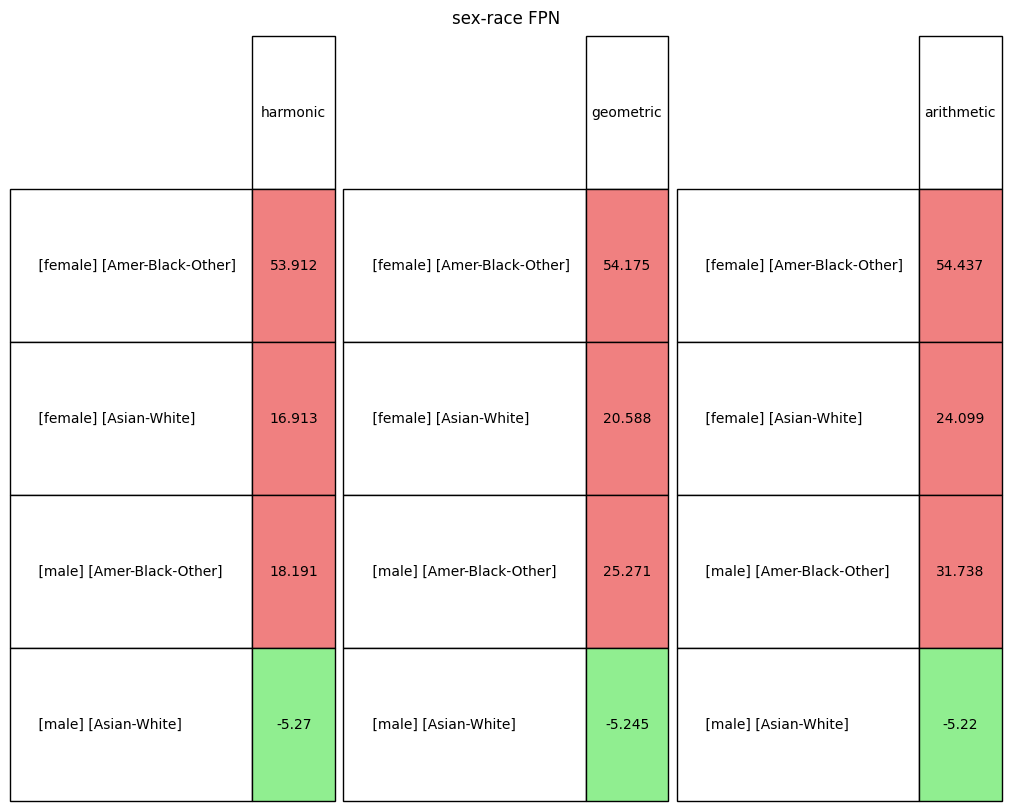

---